In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arshkon/linkedin-job-postings/postings.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/companies.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/company_industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/company_specialities.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/employee_counts.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/skills.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/benefits.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_skills.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/salaries.csv
/kaggle/input/datasets/srichetanbadugu/dataset/Sri Chetan Badugu.pdf


## Import basic libraries

In [2]:
import os
import re
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("/kaggle/input/datasets/arshkon/linkedin-job-postings/postings.csv")

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 123849
Columns: 31


In [5]:
display(df.head())

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [7]:
df.isnull().sum().sort_values(ascending=False)

closed_time                   122776
skills_desc                   121410
med_salary                    117569
remote_allowed                108603
applies                       100529
min_salary                     94056
max_salary                     94056
currency                       87776
compensation_type              87776
pay_period                     87776
normalized_salary              87776
posting_domain                 39968
application_url                36665
formatted_experience_level     29409
fips                           27415
zip_code                       20872
company_name                    1719
company_id                      1717
views                           1689
description                        7
job_id                             0
title                              0
location                           0
original_listed_time               0
formatted_work_type                0
application_type                   0
expiry                             0
l

## TEXT PREPROCESSING

In [8]:
# Step 4: Select required columns
job_columns = [
    "job_id",
    "company_name",
    "title",
    "description",
    "location",
    "formatted_work_type",
    "formatted_experience_level",
    "remote_allowed",
    "work_type",
    "skills_desc"
]

df_jobs = df[job_columns].copy()

# Step 5: Handle missing values
df_jobs = df_jobs.dropna(
    subset=["title", "description"]
).copy()

df_jobs["company_name"] = df_jobs["company_name"].fillna("Unknown")
df_jobs["formatted_experience_level"] = (
    df_jobs["formatted_experience_level"].fillna("Not Specified")
)
df_jobs["skills_desc"] = df_jobs["skills_desc"].fillna("")
df_jobs["remote_allowed"] = df_jobs["remote_allowed"].fillna(0)

# Step 6: Remove duplicate jobs
df_jobs = df_jobs.drop_duplicates(
    subset=["job_id"]
).copy()

print("df_jobs created successfully!")
print("Final shape:", df_jobs.shape)

df_jobs created successfully!
Final shape: (123842, 10)


In [9]:
import re

def clean_text(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df_jobs["clean_description"] = df_jobs["description"].apply(clean_text)

print("Text cleaning completed!")

Text cleaning completed!


In [10]:
display(
    df_jobs[
        ["description", "clean_description"]
    ].head(5)
)

,description,clean_description
0,Job descriptionA leading real estate firm in N...,Job descriptionA leading real estate firm in N...
1,"At Aspen Therapy and Wellness , we are committ...","At Aspen Therapy and Wellness , we are committ..."
2,The National Exemplar is accepting application...,The National Exemplar is accepting application...
3,Senior Associate Attorney - Elder Law / Trusts...,Senior Associate Attorney - Elder Law / Trusts...
4,Looking for HVAC service tech with experience ...,Looking for HVAC service tech with experience ...


## Create Final Job Text

In [11]:
df_jobs["job_text"] = (
    "Job Title: "
    + df_jobs["title"].astype(str)
    + ". Job Description: "
    + df_jobs["clean_description"].astype(str)
)

print("Final job text created successfully!")

Final job text created successfully!


In [12]:
df_jobs[["title", "clean_description", "job_text"]].head(5)

,title,clean_description,job_text
0,Marketing Coordinator,Job descriptionA leading real estate firm in N...,Job Title: Marketing Coordinator. Job Descript...
1,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",Job Title: Mental Health Therapist/Counselor. ...
2,Assitant Restaurant Manager,The National Exemplar is accepting application...,Job Title: Assitant Restaurant Manager. Job De...
3,Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,Job Title: Senior Elder Law / Trusts and Estat...
4,Service Technician,Looking for HVAC service tech with experience ...,Job Title: Service Technician. Job Descriptio...


In [13]:
print(df_jobs["job_text"].iloc[0])

Job Title: Marketing Coordinator. Job Description: Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, ambitious members of the sales team and our dynamic executive team on a daily basis. This is an opportunity to be part of a fast-growing, highly respected real estate brokerage with a reputation for exceptional marketing and extraordinary culture of cooperation and inclusion.Who you are:You must be a well-organized, creative, proactive, positive, and most importantly, kind-hearted person. Please, be responsible, respectful, and cool-under-pressure. Please, be proficient in Adobe Creative Cloud (Indesign, Illustrator, Photoshop) and Microsoft Office Suite. Above all, have fantastic taste and be a good-hearted, fun-loving person who loves working with people and is eager to learn.Role:Our office is a fast-paced environment. You’ll work directly w

In [14]:
df_jobs["job_text"]

0         Job Title: Marketing Coordinator. Job Descript...
1         Job Title: Mental Health Therapist/Counselor. ...
2         Job Title: Assitant Restaurant Manager. Job De...
3         Job Title: Senior Elder Law / Trusts and Estat...
4         Job Title:  Service Technician. Job Descriptio...
                                ...                        
123844    Job Title: Title IX/Investigations Attorney. J...
123845    Job Title: Staff Software Engineer, ML Serving...
123846    Job Title: Account Executive, Oregon/Washingto...
123847    Job Title: Business Development Manager. Job D...
123848    Job Title: Marketing Social Media Specialist. ...
Name: job_text, Length: 123842, dtype: object

## Explore Text Data

In [15]:
# Character count
df_jobs["text_length"] = df_jobs["job_text"].str.len()

# Word count
df_jobs["word_count"] = df_jobs["job_text"].str.split().str.len()

print("Text exploration completed!")

Text exploration completed!


In [16]:
df_jobs[["text_length", "word_count"]].describe()

,text_length,word_count
count,123842.000000,123842.000000
mean,3801.010812,531.081612
std,2132.351141,302.136657
min,38.000000,6.000000
25%,2221.000000,306.000000
50%,3476.000000,485.000000
75%,5013.000000,704.000000
max,23210.000000,3411.000000


In [17]:
short_jobs = df_jobs[
    df_jobs["word_count"] < 20
]

print("Jobs with less than 20 words:", len(short_jobs))

display(
    short_jobs[
        ["title", "job_text", "word_count"]
    ].head(10)
)

Jobs with less than 20 words: 131


,title,job_text,word_count
1436,Chief Executive Officer,Job Title: Chief Executive Officer. Job Descri...,8
2443,Director of Business Development,Job Title: Director of Business Development. J...,12
2463,Network Security Specialist,Job Title: Network Security Specialist. Job De...,9
2512,Sales Specialist,Job Title: Sales Specialist. Job Description: ...,13
2826,Independent Jeweler,Job Title: Independent Jeweler. Job Descriptio...,11
3591,Senior Software Engineer,Job Title: Senior Software Engineer. Job Descr...,7
3899,Graphic Designer,Job Title: Graphic Designer. Job Description: ...,15
5665,Speech Language Pathologist,Job Title: Speech Language Pathologist. Job De...,18
6118,Delivery Driver,Job Title: Delivery Driver. Job Description: P...,9
6149,Business Development Manager,Job Title: Business Development Manager. Job D...,14


In [18]:
long_jobs = df_jobs[
    df_jobs["word_count"] > 1000
]

print("Jobs with more than 1000 words:", len(long_jobs))

long_jobs[["title", "word_count"]].head(10)

Jobs with more than 1000 words: 9005


,title,word_count
12,Appalachian Highlands Women's Business Center,1198
107,Histologist - HT,1216
209,Director of Finance,1109
211,Executive Personal Assistant,1459
265,Sales Consultant (Outside Sales),1099
282,House Coordinator,1232
284,Unpaid Internship: Development Team,1061
339,Associate Director of Individual Giving,1331
357,"Field Office ISSM - Open Rank-RS-Albuquerque, NM",1556
358,"Field Office ISSM - Open Rank-RS-Albuquerque, NM",1660


## Create the technical skill vocabulary

In [19]:
technical_skills = [
    # Programming
    "Python",
    "Java",
    "JavaScript",
    "TypeScript",
    "C++",
    "C#",
    "PHP",
    "Ruby",
    "Scala",
    "Kotlin",
    "Swift",

    # Data & Analytics
    "SQL",
    "Excel",
    "Power BI",
    "Tableau",
    "Looker",
    "Qlik",
    "Alteryx",
    "SAS",
    "SPSS",

    # AI & Machine Learning
    "Machine Learning",
    "Deep Learning",
    "Artificial Intelligence",
    "Data Science",
    "Natural Language Processing",
    "NLP",
    "Computer Vision",
    "Generative AI",
    "Large Language Models",
    "LLM",
    "BERT",
    "Transformers",
    "TensorFlow",
    "PyTorch",
    "Keras",
    "Scikit-learn",
    "XGBoost",

    # Cloud
    "AWS",
    "Azure",
    "Google Cloud",
    "Google Cloud Platform",
    "GCP",
    "EC2",
    "S3",
    "Lambda",
    "Redshift",
    "SageMaker",

    # Databases
    "MySQL",
    "PostgreSQL",
    "Oracle",
    "SQL Server",
    "SQLite",
    "MongoDB",
    "Redis",
    "Cassandra",
    "DynamoDB",

    # Big Data
    "Spark",
    "Hadoop",
    "Kafka",
    "Hive",
    "Databricks",

    # DevOps
    "Docker",
    "Kubernetes",
    "Jenkins",
    "Terraform",
    "Ansible",
    "Git",
    "GitHub",
    "GitLab",
    "CI/CD",

    # Web Development
    "HTML",
    "CSS",
    "React",
    "Angular",
    "Vue",
    "Node.js",
    "Express",
    "Django",
    "Flask",
    "FastAPI",

    # Generative AI
    "RAG",
    "LangChain",
    "LlamaIndex",
    "OpenAI",
    "Ollama",
    "Prompt Engineering",
    "Fine-tuning",

    # Business / Tools
    "Agile",
    "Scrum",
    "Jira",
    "Confluence",
    "Project Management",
    "Product Management",
    "CRM",
    "Salesforce"
]

print("Total skills:", len(technical_skills))

Total skills: 95


In [20]:
df_job_skills = pd.read_csv(
    "/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_skills.csv"
)

df_skills = pd.read_csv(
    "/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/skills.csv"
)

print("job_skills shape:", df_job_skills.shape)
print("skills shape:", df_skills.shape)

display(df_job_skills.head())
display(df_skills.head())

job_skills shape: (213768, 2)
skills shape: (35, 2)


,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN


,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution


In [21]:
df_job_skills_named = df_job_skills.merge(
    df_skills,
    on="skill_abr",
    how="left"
)

print("Shape:", df_job_skills_named.shape)

display(df_job_skills_named.head())

Shape: (213768, 3)


,job_id,skill_abr,skill_name
0,3884428798,MRKT,Marketing
1,3884428798,PR,Public Relations
2,3884428798,WRT,Writing/Editing
3,3887473071,SALE,Sales
4,3887465684,FIN,Finance


In [22]:
print(
    "Missing skill names:",
    df_job_skills_named["skill_name"].isnull().sum()
)

Missing skill names: 0


In [23]:
job_skill_groups = (
    df_job_skills_named
    .dropna(subset=["skill_name"])
    .groupby("job_id")["skill_name"]
    .apply(list)
    .reset_index()
)

job_skill_groups.columns = [
    "job_id",
    "structured_skills"
]

display(job_skill_groups.head())

,job_id,structured_skills
0,921716,"[Marketing, Sales]"
1,1218575,[Health Care Provider]
2,1829192,[Health Care Provider]
3,2264355,"[Design, Art/Creative, Information Technology]"
4,10998357,"[Management, Manufacturing]"


## Create skill-category mapping

In [24]:
skill_categories = {

    "Marketing": "Business & Marketing",
    "Sales": "Business & Marketing",
    "Management": "Business & Management",
    "Project Management": "Business & Management",

    "Information Technology": "Technology",
    "Engineering": "Engineering",
    "Design": "Design & Creative",
    "Art/Creative": "Design & Creative",

    "Finance": "Finance",
    "Accounting": "Finance",

    "Health Care Provider": "Healthcare",
    "Health Care": "Healthcare",

    "Human Resources": "Human Resources",
    "Legal": "Legal",

    "Customer Service": "Customer Service",
    "Administrative": "Administration",

    "Manufacturing": "Manufacturing",
    "Quality Assurance": "Quality & Operations",

    "Education": "Education",
    "Research": "Research",

    "Writing/Editing": "Content & Communication",
    "Media/Communication": "Content & Communication"
}

In [25]:
def categorize_skill(skill):
    return skill_categories.get(skill, "Other")

In [26]:
test_skills = [
    "Marketing",
    "Information Technology",
    "Management",
    "Design",
    "Manufacturing"
]

for skill in test_skills:
    print(skill, "→", categorize_skill(skill))

Marketing → Business & Marketing
Information Technology → Technology
Management → Business & Management
Design → Design & Creative
Manufacturing → Manufacturing


In [27]:
print(df_jobs.columns.tolist())

['job_id', 'company_name', 'title', 'description', 'location', 'formatted_work_type', 'formatted_experience_level', 'remote_allowed', 'work_type', 'skills_desc', 'clean_description', 'job_text', 'text_length', 'word_count']


In [28]:
df_job_skills = pd.read_csv(
    "/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_skills.csv"
)

df_skills = pd.read_csv(
    "/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/skills.csv"
)

print("job_skills shape:", df_job_skills.shape)
print("skills shape:", df_skills.shape)

job_skills shape: (213768, 2)
skills shape: (35, 2)


In [29]:
df_job_skills_named = df_job_skills.merge(
    df_skills,
    on="skill_abr",
    how="left"
)

display(df_job_skills_named.head())

,job_id,skill_abr,skill_name
0,3884428798,MRKT,Marketing
1,3884428798,PR,Public Relations
2,3884428798,WRT,Writing/Editing
3,3887473071,SALE,Sales
4,3887465684,FIN,Finance


In [30]:
job_skill_groups = (
    df_job_skills_named
    .dropna(subset=["skill_name"])
    .groupby("job_id")["skill_name"]
    .apply(list)
    .reset_index()
)

job_skill_groups.columns = [
    "job_id",
    "structured_skills"
]

display(job_skill_groups.head())

,job_id,structured_skills
0,921716,"[Marketing, Sales]"
1,1218575,[Health Care Provider]
2,1829192,[Health Care Provider]
3,2264355,"[Design, Art/Creative, Information Technology]"
4,10998357,"[Management, Manufacturing]"


In [31]:
df_jobs = df_jobs.merge(
    job_skill_groups,
    on="job_id",
    how="left"
)

In [32]:
df_jobs["structured_skills"] = df_jobs["structured_skills"].apply(
    lambda x: x if isinstance(x, list) else []
)

In [33]:
print(df_jobs.columns.tolist())

display(
    df_jobs[
        ["job_id", "title", "structured_skills"]
    ].head(10)
)

['job_id', 'company_name', 'title', 'description', 'location', 'formatted_work_type', 'formatted_experience_level', 'remote_allowed', 'work_type', 'skills_desc', 'clean_description', 'job_text', 'text_length', 'word_count', 'structured_skills']


,job_id,title,structured_skills
0,921716,Marketing Coordinator,"[Marketing, Sales]"
1,1829192,Mental Health Therapist/Counselor,[Health Care Provider]
2,10998357,Assitant Restaurant Manager,"[Management, Manufacturing]"
3,23221523,Senior Elder Law / Trusts and Estates Associat...,[Other]
4,35982263,Service Technician,[Information Technology]
5,91700727,Economic Development and Planning Intern,[Project Management]
6,103254301,Producer,"[Design, Art/Creative, Information Technology]"
7,112576855,Building Engineer,"[Management, Manufacturing]"
8,1218575,Respiratory Therapist,[Health Care Provider]
9,2264355,Worship Leader,"[Design, Art/Creative, Information Technology]"


In [34]:
df_jobs["skill_categories"] = df_jobs["structured_skills"].apply(
    lambda skills: list(set(
        categorize_skill(skill)
        for skill in skills
    ))
)

In [35]:
df_jobs["skill_categories"] = df_jobs["structured_skills"].apply(
    lambda skills: list(set(
        categorize_skill(skill)
        for skill in skills
    ))
)

## Analyze Skill Demand

In [36]:
skill_demand = (
    df_job_skills_named
    .dropna(subset=["skill_name"])
    .groupby("skill_name")["job_id"]
    .nunique()
    .reset_index()
)

skill_demand.columns = [
    "skill",
    "job_count"
]

skill_demand = skill_demand.sort_values(
    "job_count",
    ascending=False
)

display(skill_demand.head(20))

,skill,job_count
16,Information Technology,26137
29,Sales,22475
18,Management,20861
19,Manufacturing,18185
14,Health Care Provider,17369
5,Business Development,14290
11,Engineering,13009
21,Other,12608
12,Finance,8540
20,Marketing,5525


In [37]:
total_jobs = df_jobs["job_id"].nunique()

skill_demand["demand_percentage"] = (
    skill_demand["job_count"] / total_jobs * 100
)

display(skill_demand.head(20))

,skill,job_count,demand_percentage
16,Information Technology,26137,21.105118
29,Sales,22475,18.148124
18,Management,20861,16.844851
19,Manufacturing,18185,14.684033
14,Health Care Provider,17369,14.025129
5,Business Development,14290,11.538896
11,Engineering,13009,10.504514
21,Other,12608,10.180714
12,Finance,8540,6.895883
20,Marketing,5525,4.461330


In [38]:
top_skills = skill_demand.head(20)

display(top_skills)

,skill,job_count,demand_percentage
16,Information Technology,26137,21.105118
29,Sales,22475,18.148124
18,Management,20861,16.844851
19,Manufacturing,18185,14.684033
14,Health Care Provider,17369,14.025129
5,Business Development,14290,11.538896
11,Engineering,13009,10.504514
21,Other,12608,10.180714
12,Finance,8540,6.895883
20,Marketing,5525,4.461330


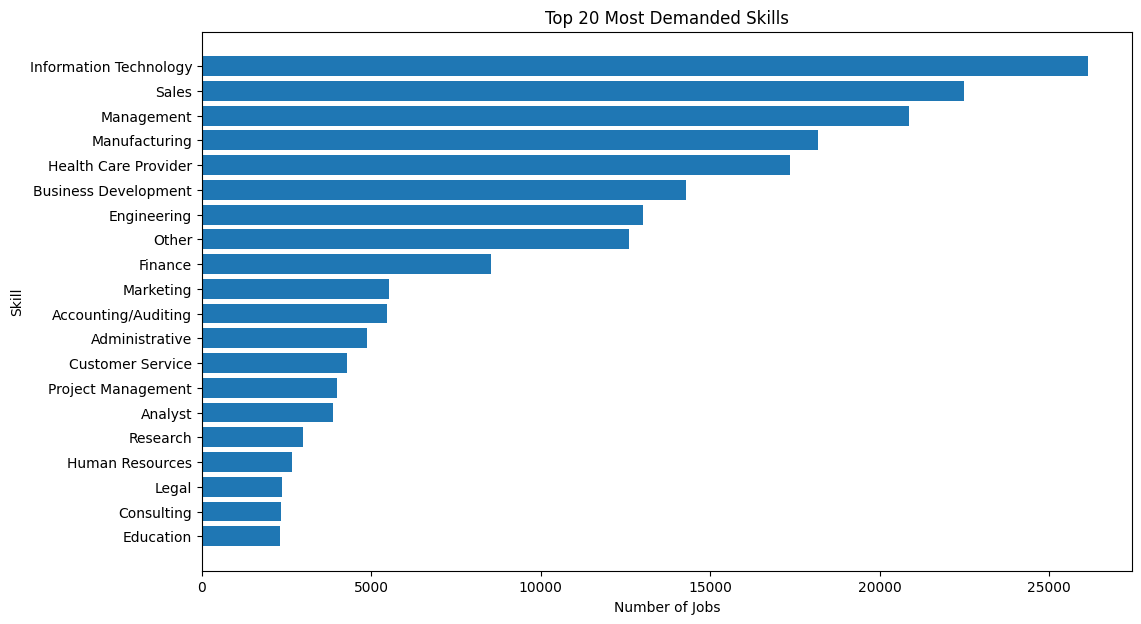

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.barh(
    top_skills["skill"][::-1],
    top_skills["job_count"][::-1]
)

plt.xlabel("Number of Jobs")
plt.ylabel("Skill")
plt.title("Top 20 Most Demanded Skills")

plt.show()

In [40]:
category_demand = (
    df_jobs[
        ["job_id", "skill_categories"]
    ]
    .explode("skill_categories")
    .dropna(subset=["skill_categories"])
)

In [41]:
category_demand = (
    category_demand
    .groupby("skill_categories")["job_id"]
    .nunique()
    .reset_index()
)

category_demand.columns = [
    "category",
    "job_count"
]

category_demand = category_demand.sort_values(
    "job_count",
    ascending=False
)

display(category_demand)

,category,job_count
13,Other,44711
16,Technology,25255
2,Business & Marketing,24295
1,Business & Management,23919
12,Manufacturing,17728
9,Healthcare,16675
7,Engineering,12530
8,Finance,8009
0,Administration,4787
4,Customer Service,4167


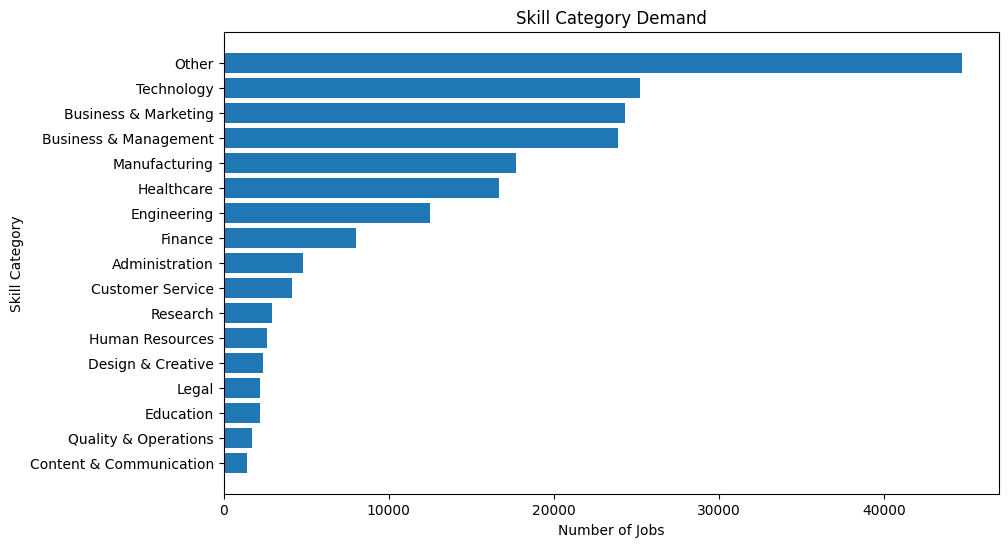

In [42]:
plt.figure(figsize=(10, 6))

plt.barh(
    category_demand["category"][::-1],
    category_demand["job_count"][::-1]
)

plt.xlabel("Number of Jobs")
plt.ylabel("Skill Category")
plt.title("Skill Category Demand")

plt.show()

In [43]:
job_categories = {
    "AI & Machine Learning": [
        "machine learning",
        "ml engineer",
        "artificial intelligence",
        "ai engineer",
        "deep learning",
        "nlp",
        "natural language processing",
        "computer vision",
        "data scientist"
    ],

    "Data & Analytics": [
        "data analyst",
        "data analytics",
        "business analyst",
        "business intelligence",
        "bi analyst",
        "data engineer",
        "analytics"
    ],

    "Software Development": [
        "software engineer",
        "software developer",
        "python developer",
        "java developer",
        "frontend developer",
        "backend developer",
        "full stack",
        "web developer",
        "application developer"
    ],

    "Cloud & IT": [
        "cloud engineer",
        "cloud architect",
        "devops",
        "site reliability",
        "systems engineer",
        "network engineer",
        "it support",
        "it specialist",
        "cybersecurity",
        "security engineer"
    ],

    "Business & Management": [
        "project manager",
        "product manager",
        "program manager",
        "operations manager",
        "business manager",
        "management"
    ],

    "Sales & Marketing": [
        "sales",
        "marketing",
        "business development",
        "account executive",
        "marketing manager",
        "sales manager"
    ],

    "Finance & Accounting": [
        "accountant",
        "accounting",
        "financial analyst",
        "finance",
        "banking",
        "auditor"
    ],

    "Healthcare": [
        "nurse",
        "doctor",
        "physician",
        "healthcare",
        "medical",
        "clinical",
        "pharmacy"
    ],

    "Engineering": [
        "mechanical engineer",
        "electrical engineer",
        "civil engineer",
        "chemical engineer",
        "industrial engineer"
    ]
}

In [44]:
def classify_job(title):

    title = str(title).lower()

    for category, keywords in job_categories.items():

        for keyword in keywords:

            if keyword in title:
                return category

    return "Other"

In [45]:
df_jobs["job_category"] = df_jobs["title"].apply(
    classify_job
)

In [46]:
category_counts = (
    df_jobs["job_category"]
    .value_counts()
)

display(category_counts)

job_category
Other                    87409
Sales & Marketing        11796
Healthcare                8997
Business & Management     5299
Finance & Accounting      3403
Software Development      2262
Data & Analytics          1837
Cloud & IT                1508
Engineering                844
AI & Machine Learning      487
Name: count, dtype: int64

In [47]:
category_percentage = (
    df_jobs["job_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(category_percentage)

job_category
Other                    70.58
Sales & Marketing         9.53
Healthcare                7.26
Business & Management     4.28
Finance & Accounting      2.75
Software Development      1.83
Data & Analytics          1.48
Cloud & IT                1.22
Engineering               0.68
AI & Machine Learning     0.39
Name: proportion, dtype: float64

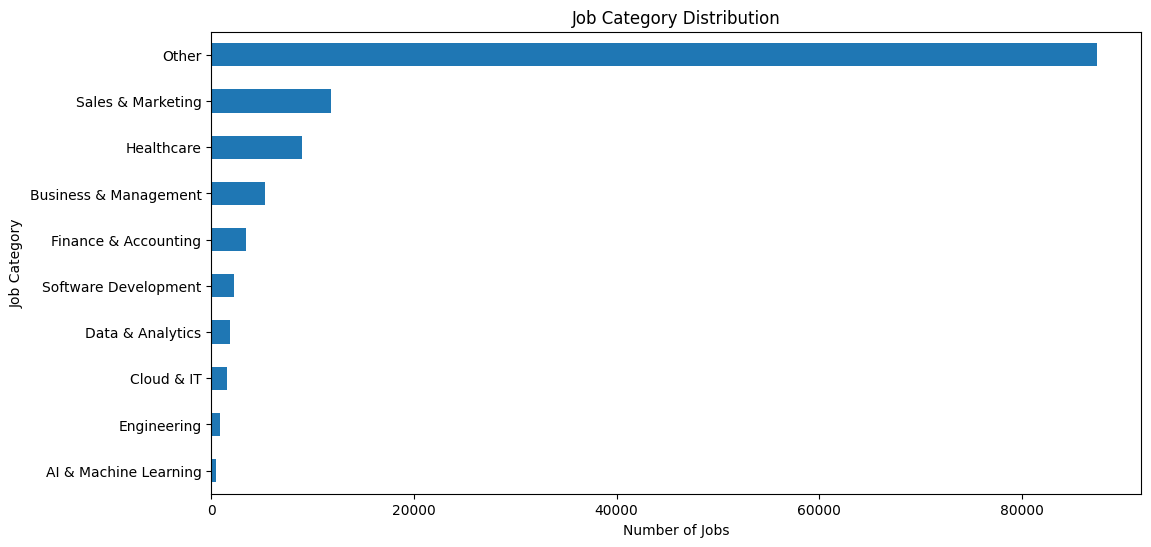

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

category_counts.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of Jobs")
plt.ylabel("Job Category")
plt.title("Job Category Distribution")

plt.show()

In [49]:
print(
    "Other jobs:",
    (df_jobs["job_category"] == "Other").sum()
)

print(
    "Other percentage:",
    round(
        (df_jobs["job_category"] == "Other").mean() * 100,
        2
    ),
    "%"
)

Other jobs: 87409
Other percentage: 70.58 %


In [50]:
other_jobs = df_jobs[
    df_jobs["job_category"] == "Other"
]

display(
    other_jobs[["title"]]
    .sample(50, random_state=42)
)

,title
51814,HR Recruiter and Coordinator-24-00446
74229,Team Member FT/PT 2nd/3rd Shifts W/DAILY Avail...
82489,Gas and Construction Inspector
110086,Facilities Planning Analyst
57596,Worker's Compensation Attorney
121840,Electrical Technician
2589,Environmental Compliance Inspector
66594,"Manager, Corporate FP&A (Consolidation) - Deca..."
18437,Mechanical Design Engineer
35728,"Diesel Mechanic, $2,500 Sign on Bonus and Relo..."


In [51]:
other_title_counts = (
    other_jobs["title"]
    .value_counts()
    .head(50)
)

display(other_title_counts)

title
Customer Service Representative                 373
Administrative Assistant                        254
Executive Assistant                             228
Receptionist                                    204
Controller                                      175
Account Manager                                 171
Store Manager                                   166
Assistant Manager                               161
ASSISTANT STORE MANAGER                         161
Maintenance Technician                          155
Assistant Store Manager                         155
General Manager                                 135
Service Technician                              123
OPERATIONS ASSISTANT MANAGER                    114
Package Handler - Part Time (Warehouse like)    112
Patient Care Technician                         110
Associate Attorney                              109
Physical Therapist                              109
CUSTOMER SERVICE REPRESENTATIVE                 107
Wareho

In [52]:
display(
    df_jobs["job_category"]
    .value_counts()
)

job_category
Other                    87409
Sales & Marketing        11796
Healthcare                8997
Business & Management     5299
Finance & Accounting      3403
Software Development      2262
Data & Analytics          1837
Cloud & IT                1508
Engineering                844
AI & Machine Learning      487
Name: count, dtype: int64

## Improve & Validate Job Categories

In [53]:
def classify_job(title):

    title = str(title).lower()

    # AI & Machine Learning
    if any(keyword in title for keyword in [
        "machine learning", "ml engineer", "artificial intelligence",
        "ai engineer", "deep learning", "nlp",
        "natural language", "computer vision", "data scientist"
    ]):
        return "AI & Machine Learning"

    # Data & Analytics
    elif any(keyword in title for keyword in [
        "data analyst", "data analytics", "data engineer",
        "business analyst", "business intelligence",
        "bi analyst", "analytics", "reporting analyst",
        "data quality", "data architect"
    ]):
        return "Data & Analytics"

    # Software Development
    elif any(keyword in title for keyword in [
        "software engineer", "software developer",
        "developer", "programmer", "web developer",
        "frontend", "front end", "backend", "back end",
        "full stack", "full-stack", "application developer",
        "mobile developer", "ios developer", "android developer",
        "java developer", "python developer"
    ]):
        return "Software Development"

    # Cloud & IT
    elif any(keyword in title for keyword in [
        "cloud", "devops", "site reliability", "sre",
        "system administrator", "systems administrator",
        "systems engineer", "network engineer",
        "network administrator", "it support", "information technology",
        "cyber security", "cybersecurity", "security engineer",
        "technical support", "infrastructure"
    ]):
        return "Cloud & IT"

    # Business & Management
    elif any(keyword in title for keyword in [
        "project manager", "product manager", "program manager",
        "operations manager", "business manager",
        "general manager", "management", "manager",
        "director", "vice president", "vp ",
        "chief", "supervisor", "team lead", "lead"
    ]):
        return "Business & Management"

    # Sales & Marketing
    elif any(keyword in title for keyword in [
        "sales", "marketing", "business development",
        "account executive", "account manager",
        "sales representative", "sales associate",
        "marketing specialist", "marketing coordinator",
        "brand manager", "growth"
    ]):
        return "Sales & Marketing"

    # Finance & Accounting
    elif any(keyword in title for keyword in [
        "accountant", "accounting", "financial analyst",
        "finance", "banking", "auditor",
        "controller", "bookkeeper", "investment",
        "tax analyst", "credit analyst"
    ]):
        return "Finance & Accounting"

    # Healthcare
    elif any(keyword in title for keyword in [
        "nurse", "nursing", "doctor", "physician",
        "healthcare", "health care", "medical",
        "clinical", "pharmacy", "therapist",
        "dental", "hospital"
    ]):
        return "Healthcare"

    # Engineering
    elif any(keyword in title for keyword in [
        "mechanical engineer", "electrical engineer",
        "civil engineer", "chemical engineer",
        "industrial engineer", "manufacturing engineer",
        "quality engineer", "process engineer",
        "engineering"
    ]):
        return "Engineering"

    else:
        return "Other"

In [54]:
df_jobs["job_category"] = df_jobs["title"].apply(
    classify_job
)

In [55]:
category_counts = (
    df_jobs["job_category"]
    .value_counts()
)

display(category_counts)

job_category
Other                    60882
Business & Management    29303
Healthcare               10768
Sales & Marketing         8179
Software Development      4388
Finance & Accounting      3256
Cloud & IT                2808
Data & Analytics          2001
Engineering               1770
AI & Machine Learning      487
Name: count, dtype: int64

In [56]:
category_percentage = (
    df_jobs["job_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(category_percentage)

job_category
Other                    49.16
Business & Management    23.66
Healthcare                8.69
Sales & Marketing         6.60
Software Development      3.54
Finance & Accounting      2.63
Cloud & IT                2.27
Data & Analytics          1.62
Engineering               1.43
AI & Machine Learning     0.39
Name: proportion, dtype: float64

In [57]:
other_count = (
    df_jobs["job_category"] == "Other"
).sum()

other_percentage = (
    df_jobs["job_category"] == "Other"
).mean() * 100

print("Other jobs:", other_count)
print("Other percentage:", round(other_percentage, 2), "%")

Other jobs: 60882
Other percentage: 49.16 %


In [58]:
display(
    df_jobs[
        ["title", "job_category"]
    ].sample(50, random_state=42)
)

,title,job_category
73452,Warehouse,Other
31561,Influencer Talent Manager - Beauty,Business & Management
41618,Talent Attraction Specialist,Other
10762,Retail Sales - Shoes - Stonebriar Centre,Sales & Marketing
30332,"Physician Assistant, Per Diem - Internal Medicine",Healthcare
109320,Application Development - Permit Coordinator IV,Other
97589,Multimedia Journalist,Other
105245,Regional Banking Manager (SAFE),Business & Management
34454,Technical Director,Business & Management
65338,Laboratory Assistant,Other


In [59]:
from sklearn.model_selection import train_test_split

model_df = df_jobs[
    ["job_text", "job_category"]
].copy()

print("Total records:", len(model_df))
display(model_df.head())

Total records: 123842


,job_text,job_category
0,Job Title: Marketing Coordinator. Job Descript...,Sales & Marketing
1,Job Title: Mental Health Therapist/Counselor. ...,Healthcare
2,Job Title: Assitant Restaurant Manager. Job De...,Business & Management
3,Job Title: Senior Elder Law / Trusts and Estat...,Other
4,Job Title: Service Technician. Job Descriptio...,Other


In [60]:
model_df = model_df.dropna(
    subset=["job_text", "job_category"]
).copy()

print("Records after cleaning:", len(model_df))

Records after cleaning: 123842


In [61]:
train_df, temp_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42,
    stratify=model_df["job_category"]
)

print("Training:", len(train_df))
print("Temporary:", len(temp_df))

Training: 99073
Temporary: 24769


In [62]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["job_category"]
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Training: 99073
Validation: 12384
Test: 12385


In [63]:
print("TRAINING DISTRIBUTION")
display(train_df["job_category"].value_counts(normalize=True).mul(100).round(2))

print("VALIDATION DISTRIBUTION")
display(val_df["job_category"].value_counts(normalize=True).mul(100).round(2))

print("TEST DISTRIBUTION")
display(test_df["job_category"].value_counts(normalize=True).mul(100).round(2))

TRAINING DISTRIBUTION


job_category
Other                    49.16
Business & Management    23.66
Healthcare                8.69
Sales & Marketing         6.60
Software Development      3.54
Finance & Accounting      2.63
Cloud & IT                2.27
Data & Analytics          1.62
Engineering               1.43
AI & Machine Learning     0.39
Name: proportion, dtype: float64

VALIDATION DISTRIBUTION


job_category
Other                    49.16
Business & Management    23.66
Healthcare                8.70
Sales & Marketing         6.61
Software Development      3.54
Finance & Accounting      2.62
Cloud & IT                2.27
Data & Analytics          1.61
Engineering               1.43
AI & Machine Learning     0.40
Name: proportion, dtype: float64

TEST DISTRIBUTION


job_category
Other                    49.16
Business & Management    23.67
Healthcare                8.70
Sales & Marketing         6.60
Software Development      3.54
Finance & Accounting      2.63
Cloud & IT                2.26
Data & Analytics          1.61
Engineering               1.43
AI & Machine Learning     0.39
Name: proportion, dtype: float64

In [64]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

## DistilBERT

In [65]:
!pip install -q "transformers==4.46.3" "tf-keras>=2.16.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 82.2 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.0 MB/s eta 0:00:00:00:01


In [66]:
import numpy as np
import pandas as pd
import tensorflow as tf

from transformers import AutoTokenizer,TFAutoModelForSequenceClassification

In [67]:
MODEL_NAME = "distilbert-base-uncased"

MAX_LENGTH = 128

In [68]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully!


In [69]:
sample_text = train_df["job_text"].iloc[0]

tokens = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH
)

print("Input IDs:")
print(tokens["input_ids"][:20])

print("\nAttention Mask:")
print(tokens["attention_mask"][:20])

Input IDs:
[101, 3105, 2516, 1024, 4170, 6032, 16661, 3523, 1006, 4705, 1007, 1012, 3105, 6412, 1024, 3105, 4751, 3105, 3295, 2531]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [70]:
print("Original job text:")
print(sample_text[:1000])

Original job text:
Job Title: Fleet Maintenance Technician III (KG). Job Description: Job Details Job Location 10069 - Plant City Fleet Plant City FL - Plant City, FL Position Type Full Time Education Level Not Specified Travel Percentage None Job Category Automotive Description Job Title: Fleet Maintenance Technician III Department: Fleet Operations & Maintenance Job Summary: Under general supervision, diagnose, maintain, repair, and service a wide variety of fleet vehicles, equipment, and specialized vehicles. Supervisory Responsibilities: None Duties/Responsibilities: Diagnose, perform maintenance, and repair on light, medium, and heavy vehicles and equipmentService vehicles with fuel, oil, and coolant; perform preventive maintenance by checking items such as battery condition, tire air pressure, coolant and oil levels, and hydraulic and brake fluid levelsPerforms skilled repair and maintenance on a variety of gasoline-powered equipment and vehicles, such as replacing bearings, axle

In [71]:
print("\nTokens:")
print(
    tokenizer.convert_ids_to_tokens(
        tokens["input_ids"][:30]
    )
)


Tokens:
['[CLS]', 'job', 'title', ':', 'fleet', 'maintenance', 'technician', 'iii', '(', 'kg', ')', '.', 'job', 'description', ':', 'job', 'details', 'job', 'location', '100', '##6', '##9', '-', 'plant', 'city', 'fleet', 'plant', 'city', 'fl', '-']


In [72]:
def tokenize_texts(texts):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [73]:
train_encodings = tokenize_texts(
    train_df["job_text"]
)

print("Training tokenization completed.")
print("Number of training samples:", len(train_encodings["input_ids"]))

Training tokenization completed.
Number of training samples: 99073


In [74]:
val_encodings = tokenize_texts(
    val_df["job_text"]
)

print("Validation tokenization completed.")
print("Number of validation samples:", len(val_encodings["input_ids"]))

Validation tokenization completed.
Number of validation samples: 12384


In [75]:
test_encodings = tokenize_texts(
    test_df["job_text"]
)

print("Test tokenization completed.")
print("Number of test samples:", len(test_encodings["input_ids"]))

Test tokenization completed.
Number of test samples: 12385


In [76]:
print("Input IDs shape:")
print(np.array(train_encodings["input_ids"]).shape)

print("\nAttention Mask shape:")
print(np.array(train_encodings["attention_mask"]).shape)

Input IDs shape:
(99073, 128)

Attention Mask shape:
(99073, 128)


In [77]:
print("Original text:")
print(train_df["job_text"].iloc[0][:500])

print("\nFirst 20 Input IDs:")
print(train_encodings["input_ids"][0][:20])

print("\nFirst 20 Attention Mask values:")
print(train_encodings["attention_mask"][0][:20])

Original text:
Job Title: Fleet Maintenance Technician III (KG). Job Description: Job Details Job Location 10069 - Plant City Fleet Plant City FL - Plant City, FL Position Type Full Time Education Level Not Specified Travel Percentage None Job Category Automotive Description Job Title: Fleet Maintenance Technician III Department: Fleet Operations & Maintenance Job Summary: Under general supervision, diagnose, maintain, repair, and service a wide variety of fleet vehicles, equipment, and specialized vehicles. S

First 20 Input IDs:
[101, 3105, 2516, 1024, 4170, 6032, 16661, 3523, 1006, 4705, 1007, 1012, 3105, 6412, 1024, 3105, 4751, 3105, 3295, 2531]

First 20 Attention Mask values:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [78]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_labels = label_encoder.fit_transform(
    train_df["job_category"]
)

val_labels = label_encoder.transform(
    val_df["job_category"]
)

test_labels = label_encoder.transform(
    test_df["job_category"]
)

print("Number of classes:", len(label_encoder.classes_))
print("Classes:")

for i, category in enumerate(label_encoder.classes_):
    print(i, "→", category)

Number of classes: 10
Classes:
0 → AI & Machine Learning
1 → Business & Management
2 → Cloud & IT
3 → Data & Analytics
4 → Engineering
5 → Finance & Accounting
6 → Healthcare
7 → Other
8 → Sales & Marketing
9 → Software Development


In [79]:
print("Train labels:", train_labels.shape)
print("Validation labels:", val_labels.shape)
print("Test labels:", test_labels.shape)

Train labels: (99073,)
Validation labels: (12384,)
Test labels: (12385,)


In [80]:
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "input_ids": np.array(train_encodings["input_ids"]),
            "attention_mask": np.array(train_encodings["attention_mask"])
        },
        train_labels
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "input_ids": np.array(val_encodings["input_ids"]),
            "attention_mask": np.array(val_encodings["attention_mask"])
        },
        val_labels
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "input_ids": np.array(test_encodings["input_ids"]),
            "attention_mask": np.array(test_encodings["attention_mask"])
        },
        test_labels
    )
)

I0000 00:00:1789119181.658732      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [81]:
train_dataset = (
    train_dataset
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [82]:
for batch_x, batch_y in train_dataset.take(1):

    print("Input IDs shape:",
          batch_x["input_ids"].shape)

    print("Attention Mask shape:",
          batch_x["attention_mask"].shape)

    print("Labels shape:",
          batch_y.shape)

Input IDs shape: (16, 128)
Attention Mask shape: (16, 128)
Labels shape: (16,)


## Load DistilBERT

In [83]:
num_labels = len(label_encoder.classes_)

print("Number of job categories:", num_labels)

Number of job categories: 10


In [84]:
MODEL_NAME = "distilbert-base-uncased"

model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

print("DistilBERT model loaded successfully!")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

DistilBERT model loaded successfully!


In [85]:
model.summary()

Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  7690      
                                                                 
 dropout_19 (Dropout)        multiple                  0 (unused)
                                                                 
Total params: 66961162 (255.44 MB)
Trainable params: 66961162 (255.44 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [86]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-5
)

loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [87]:
EPOCHS = 5

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/5


I0000 00:00:1789119204.779242     143 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6193/6193 [==============================] - 874s 137ms/step - loss: 0.0866 - accuracy: 0.9795 - val_loss: 0.0113 - val_accuracy: 0.9979
Epoch 2/5
6193/6193 [==============================] - 848s 137ms/step - loss: 0.0128 - accuracy: 0.9972 - val_loss: 0.0052 - val_accuracy: 0.9990
Epoch 3/5
6193/6193 [==============================] - 855s 138ms/step - loss: 0.0077 - accuracy: 0.9984 - val_loss: 0.0048 - val_accuracy: 0.9989
Epoch 4/5
6193/6193 [==============================] - 841s 136ms/step - loss: 0.0058 - accuracy: 0.9989 - val_loss: 0.0054 - val_accuracy: 0.9990
Epoch 5/5
6193/6193 [==============================] - 845s 136ms/step - loss: 0.0049 - accuracy: 0.9992 - val_loss: 0.0048 - val_accuracy: 0.9992


In [88]:
print("df_jobs:", "df_jobs" in globals())
print("model:", "model" in globals())
print("train_dataset:", "train_dataset" in globals())

df_jobs: True
model: True
train_dataset: True


In [89]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

775/775 [==============================] - 38s 50ms/step - loss: 0.0052 - accuracy: 0.9990
Test Loss: 0.005243324674665928
Test Accuracy: 0.9989503622055054


In [90]:
predictions = model.predict(test_dataset)

print(predictions.logits.shape)

775/775 [==============================] - 38s 48ms/step
(12385, 10)


In [91]:
predicted_labels = np.argmax(
    predictions.logits,
    axis=1
)

print("Predicted labels:")
print(predicted_labels[:20])

Predicted labels:
[5 1 1 1 1 1 7 7 7 6 6 6 7 7 1 9 1 3 7 1]


In [92]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        predicted_labels,
        target_names=label_encoder.classes_
    )
)

                       precision    recall  f1-score   support

AI & Machine Learning       1.00      0.96      0.98        48
Business & Management       1.00      1.00      1.00      2931
           Cloud & IT       1.00      0.99      1.00       280
     Data & Analytics       1.00      1.00      1.00       200
          Engineering       1.00      1.00      1.00       177
 Finance & Accounting       1.00      1.00      1.00       326
           Healthcare       1.00      1.00      1.00      1077
                Other       1.00      1.00      1.00      6089
    Sales & Marketing       1.00      1.00      1.00       818
 Software Development       1.00      1.00      1.00       439

             accuracy                           1.00     12385
            macro avg       1.00      0.99      1.00     12385
         weighted avg       1.00      1.00      1.00     12385



In [93]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_labels,
    predicted_labels
)

print(cm)

[[  46    0    0    1    0    0    0    1    0    0]
 [   0 2928    0    0    0    0    0    3    0    0]
 [   0    0  278    0    0    0    0    2    0    0]
 [   0    0    0  200    0    0    0    0    0    0]
 [   0    0    0    0  177    0    0    0    0    0]
 [   0    0    0    0    0  326    0    0    0    0]
 [   0    0    0    0    0    0 1077    0    0    0]
 [   0    2    0    0    0    0    1 6085    1    0]
 [   0    0    0    0    0    1    1    0  816    0]
 [   0    0    0    0    0    0    0    0    0  439]]


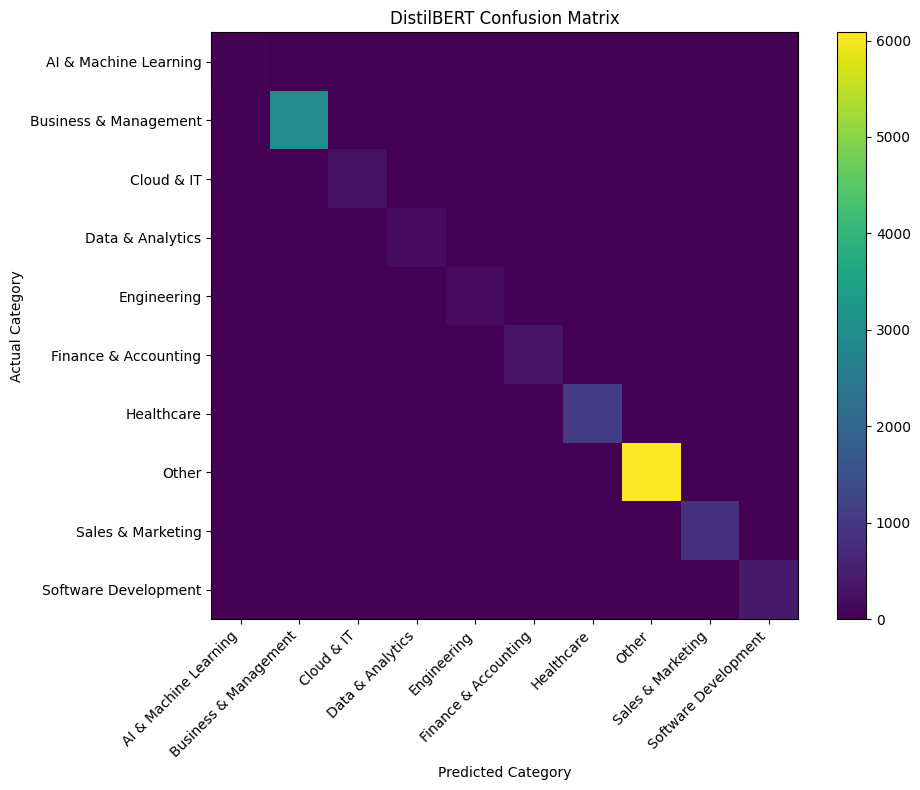

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("DistilBERT Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [95]:
import os

MODEL_DIR = "/kaggle/working/job_distilbert_model"

os.makedirs(MODEL_DIR, exist_ok=True)

print("Save folder created:")
print(MODEL_DIR)

Save folder created:
/kaggle/working/job_distilbert_model


In [96]:
model.save_pretrained(MODEL_DIR)

print("DistilBERT model saved successfully!")

DistilBERT model saved successfully!


In [97]:
tokenizer.save_pretrained(MODEL_DIR)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [98]:
import pickle

with open(
    os.path.join(MODEL_DIR, "label_encoder.pkl"),
    "wb"
) as f:

    pickle.dump(
        label_encoder,
        f
    )

print("Label encoder saved successfully!")

Label encoder saved successfully!


In [99]:
print("Saved files:")

for file in os.listdir(MODEL_DIR):
    print(file)

Saved files:
label_encoder.pkl
config.json
vocab.txt
special_tokens_map.json
tf_model.h5
tokenizer.json
tokenizer_config.json


In [100]:
new_job = """
We are looking for a Machine Learning Engineer to build and deploy
machine learning models using Python, TensorFlow and Scikit-learn.
The candidate should have experience with data preprocessing,
model training, deep learning and artificial intelligence.
"""

In [101]:
new_tokens = tokenizer(
    new_job,
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="tf"
)

In [102]:
prediction = model.predict({
    "input_ids": new_tokens["input_ids"],
    "attention_mask": new_tokens["attention_mask"]
})

predicted_class = np.argmax(
    prediction.logits,
    axis=1
)[0]

predicted_category = label_encoder.inverse_transform(
    [predicted_class]
)[0]

print("Predicted Category:", predicted_category)

1/1 [==============================] - 1s 1s/step
Predicted Category: AI & Machine Learning


In [103]:
probabilities = tf.nn.softmax(
    prediction.logits,
    axis=1
).numpy()[0]

confidence = probabilities[predicted_class] * 100

print("Predicted Category:", predicted_category)
print("Confidence:", round(confidence, 2), "%")

Predicted Category: AI & Machine Learning
Confidence: 99.97 %


In [104]:
results = pd.DataFrame({
    "Category": label_encoder.classes_,
    "Probability": probabilities * 100
})

results = results.sort_values(
    "Probability",
    ascending=False
)

display(results)

,Category,Probability
0,AI & Machine Learning,99.965622
7,Other,0.012965
3,Data & Analytics,0.010501
9,Software Development,0.004748
1,Business & Management,0.002297
4,Engineering,0.001825
2,Cloud & IT,0.001096
6,Healthcare,0.000622
8,Sales & Marketing,0.000270
5,Finance & Accounting,0.000051


In [105]:
!pip install -q pypdf

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [106]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/arshkon/linkedin-job-postings/postings.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/companies.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/company_industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/company_specialities.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/employee_counts.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/skills.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/benefits.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_skills.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/salaries.csv
/kaggle/input/datasets/srichetanbadugu/dataset/Sri Chetan Badugu.pdf


In [107]:
from pypdf import PdfReader

resume_path = "/kaggle/input/datasets/srichetanbadugu/dataset/Sri Chetan Badugu.pdf"

reader = PdfReader(resume_path)

resume_text = ""

for page in reader.pages:
    text = page.extract_text()

    if text:
        resume_text += text + "\n"

print(resume_text[:3000])

Sri Chetan Badugu
badugusrichetan@gmail.com
 
+91-9182343531
 
Linkdin
 
Github
 
Hyderabad,Telangana
 
SUMMARY
Passionate about Machine Learning, Data Science, and AI, seeking an opportunity to build a successful career in the data domain by 
leveraging my technical skills to develop data-driven solutions and deliver business value.
EDUCATION
Data Science with GEN AI, Innomatics Research Labs
Coursework in Python, Statistics, Data Analysis, SQL + PowerBI, Machine Learning, Deep Learning ANN
01/2026 – 10/2026
Hyderabad, Telangana
B.E [CSE ( AI-ML )], BHARAT INSTITUTE OF ENGINEERING AND TECHNOLOGY
CGPA - 7.25
11/2022 – 05/2026
Hyderabad, Telangana
SKILLS
Python
Python Programming, OOP, Functions, Data Structures, Exception 
Handling, File Handling, Modules & Packages, List/Dictionary/Set 
Comprehensions, Lambda Functions, NumPy, Pandas, Matplotlib, 
Seaborn, Data Cleaning, Data Manipulation & Data Visualization
Machine Learning
Supervised & Unsupervised Learning, Linear Regression, Poly

In [108]:
print("Resume characters:", len(resume_text))
print("Resume words:", len(resume_text.split()))

Resume characters: 4110
Resume words: 508


In [109]:
import re

def clean_resume_text(text):
    
    text = str(text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    
    # Remove extra spaces and new lines
    text = re.sub(r"\s+", " ", text)
    
    # Remove unnecessary special characters
    text = re.sub(r"[^\w\s.,+#/&-]", " ", text)
    
    return text.strip()

In [110]:
clean_resume = clean_resume_text(resume_text)

print(clean_resume[:3000])

Sri Chetan Badugu +91-9182343531 Linkdin Github Hyderabad,Telangana SUMMARY Passionate about Machine Learning, Data Science, and AI, seeking an opportunity to build a successful career in the data domain by leveraging my technical skills to develop data-driven solutions and deliver business value. EDUCATION Data Science with GEN AI, Innomatics Research Labs Coursework in Python, Statistics, Data Analysis, SQL + PowerBI, Machine Learning, Deep Learning ANN 01/2026   10/2026 Hyderabad, Telangana B.E  CSE   AI-ML   , BHARAT INSTITUTE OF ENGINEERING AND TECHNOLOGY CGPA - 7.25 11/2022   05/2026 Hyderabad, Telangana SKILLS Python Python Programming, OOP, Functions, Data Structures, Exception Handling, File Handling, Modules & Packages, List/Dictionary/Set Comprehensions, Lambda Functions, NumPy, Pandas, Matplotlib, Seaborn, Data Cleaning, Data Manipulation & Data Visualization Machine Learning Supervised & Unsupervised Learning, Linear Regression, Polynomial Regression, Logistic Regression, 

In [111]:
print("Original characters:", len(resume_text))
print("Cleaned characters:", len(clean_resume))

print("Original words:", len(resume_text.split()))
print("Cleaned words:", len(clean_resume.split()))

Original characters: 4110
Cleaned characters: 4047
Original words: 508
Cleaned words: 503


In [112]:
clean_resume

'Sri Chetan Badugu +91-9182343531 Linkdin Github Hyderabad,Telangana SUMMARY Passionate about Machine Learning, Data Science, and AI, seeking an opportunity to build a successful career in the data domain by leveraging my technical skills to develop data-driven solutions and deliver business value. EDUCATION Data Science with GEN AI, Innomatics Research Labs Coursework in Python, Statistics, Data Analysis, SQL + PowerBI, Machine Learning, Deep Learning ANN 01/2026   10/2026 Hyderabad, Telangana B.E  CSE   AI-ML   , BHARAT INSTITUTE OF ENGINEERING AND TECHNOLOGY CGPA - 7.25 11/2022   05/2026 Hyderabad, Telangana SKILLS Python Python Programming, OOP, Functions, Data Structures, Exception Handling, File Handling, Modules & Packages, List/Dictionary/Set Comprehensions, Lambda Functions, NumPy, Pandas, Matplotlib, Seaborn, Data Cleaning, Data Manipulation & Data Visualization Machine Learning Supervised & Unsupervised Learning, Linear Regression, Polynomial Regression, Logistic Regression,

In [113]:
!pip install -q sentence-transformers

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [114]:
from sentence_transformers import SentenceTransformer

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [115]:
from sentence_transformers import SentenceTransformer

MODEL_NAME_SBERT = "all-MiniLM-L6-v2"

sbert_model = SentenceTransformer(
    MODEL_NAME_SBERT,
    device="cpu"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [116]:
resume_embedding = sbert_model.encode(
    clean_resume,
    convert_to_numpy=True
)

In [117]:
print("Embedding shape:", resume_embedding.shape)

Embedding shape: (384,)


In [118]:
print(resume_embedding[:10])

[-0.06674828 -0.04918198 -0.00984448  0.040848    0.01922587 -0.08945387
  0.01033784  0.02291228 -0.15400603  0.02568959]


In [119]:
resume_embedding = sbert_model.encode(
    clean_resume,
    convert_to_numpy=True
)

print(resume_embedding.shape)

(384,)


In [120]:
sbert_model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    device="cpu"
)

resume_embedding = sbert_model.encode(
    clean_resume,
    convert_to_numpy=True
)

print(resume_embedding.shape)

(384,)


## Check the job data

In [121]:
print("Number of jobs:", len(df_jobs))
print(df_jobs["job_text"].isna().sum())

Number of jobs: 123842
0


## Create job text list

In [122]:
job_texts = df_jobs["job_text"].fillna("").tolist()

print("Total job texts:", len(job_texts))

Total job texts: 123842


## Generate embeddings in batches

In [123]:
job_embeddings = sbert_model.encode(
    job_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/3871 [00:00<?, ?it/s]

In [124]:
print("Job embeddings shape:", job_embeddings.shape)

Job embeddings shape: (123842, 384)


## Save the embeddings

In [125]:
import numpy as np

np.save(
    "/kaggle/working/job_embeddings.npy",
    job_embeddings
)

In [126]:
df_jobs[["job_id", "title", "job_category"]].to_csv(
    "/kaggle/working/job_embedding_metadata.csv",
    index=False
)

In [127]:
similarity_scores = np.dot(
    job_embeddings,
    resume_embedding
)

In [128]:
print(similarity_scores.shape)

(123842,)


In [129]:
df_jobs["similarity_score"] = similarity_scores

In [130]:
df_jobs["match_percentage"] = (
    df_jobs["similarity_score"] * 100
)

In [131]:
top_jobs = (
    df_jobs
    .sort_values("similarity_score", ascending=False)
    .head(10)
)

In [132]:
top_jobs[
    [
        "job_id",
        "title",
        "company_name",
        "location",
        "job_category",
        "similarity_score",
        "match_percentage"
    ]
]

,job_id,title,company_name,location,job_category,similarity_score,match_percentage
52024,3901394474,Machine Learning Engineer- 10+year exp*,"Q1 Technologies, Inc.","Sunnyvale, CA",AI & Machine Learning,0.677378,67.737785
38762,3898161387,Python Developer with AI/ML,"Q1 Technologies, Inc.","Charlotte, NC",Software Development,0.662893,66.289284
93496,3904716772,Data Scientist,Sumeru Inc,United States,AI & Machine Learning,0.662501,66.250107
46388,3900965317,Entry Level Data Scientist,topGrads,United States,AI & Machine Learning,0.657255,65.725471
43732,3900081441,Python Developer with AI/ML Skills,Tata Consultancy Services,"Charlotte, NC",Software Development,0.655339,65.533913
68966,3902788108,Sr. Machine Learning Engineer,PubMatic,"Redwood City, CA",AI & Machine Learning,0.654706,65.470627
6066,3885107986,Data Engineer (Internship),Celebal Technologies,"Dallas, TX",Data & Analytics,0.652786,65.278580
5841,3885105100,MLE/AI Engineer Summer Intern,Unknown,San Francisco Bay Area,AI & Machine Learning,0.651939,65.193901
51762,3901392216,Sr GenAI / Machine Learning Engineer,Deltek,United States,AI & Machine Learning,0.650029,65.002892
69407,3902809268,Data Scientist (6+ years) (Fulltime),Diverse Lynx,"Bentonville, AR",AI & Machine Learning,0.648667,64.866661


In [133]:
resume_skill_list = (
    df_job_skills_named["skill_name"]
    .dropna()
    .unique()
    .tolist()
)

print("Total available skills:", len(resume_skill_list))
print(resume_skill_list)

Total available skills: 35
['Marketing', 'Public Relations', 'Writing/Editing', 'Sales', 'Finance', 'Advertising', 'Business Development', 'Engineering', 'Project Management', 'Information Technology', 'General Business', 'Administrative', 'Supply Chain', 'Manufacturing', 'Production', 'Management', 'Training', 'Other', 'Legal', 'Accounting/Auditing', 'Design', 'Research', 'Analyst', 'Consulting', 'Education', 'Purchasing', 'Customer Service', 'Quality Assurance', 'Human Resources', 'Science', 'Health Care Provider', 'Strategy/Planning', 'Art/Creative', 'Distribution', 'Product Management']


## Extract skills from the resume

In [134]:
resume_lower = clean_resume.lower()

resume_skills = []

for skill in resume_skill_list:
    
    skill_lower = skill.lower()
    
    if skill_lower in resume_lower:
        resume_skills.append(skill)

print("Resume skills found:")
print(resume_skills)

Resume skills found:
['Engineering', 'Training', 'Research', 'Education', 'Science']


## Remove duplicates

In [135]:
resume_skills = list(set(resume_skills))

print("Number of resume skills:", len(resume_skills))
print(resume_skills)

Number of resume skills: 5
['Research', 'Engineering', 'Education', 'Training', 'Science']


## Compare Resume Skills vs Job Skills

In [136]:
top_jobs = (
    df_jobs
    .sort_values("similarity_score", ascending=False)
    .head(10)
    .copy()
)

In [137]:
top_jobs_skills = top_jobs[
    ["job_id", "title", "company_name", "structured_skills"]
].copy()

## Compare one job with your resume

In [138]:
top_job_skills = top_jobs.iloc[0]["structured_skills"]

print("Job:", top_jobs.iloc[0]["title"])
print("Required skills:", top_job_skills)

Job: Machine Learning Engineer- 10+year exp*
Required skills: ['Engineering', 'Information Technology']


In [139]:
matching_skills = set(resume_skills).intersection(
    set(top_job_skills)
)

missing_skills = set(top_job_skills).difference(
    set(resume_skills)
)

In [140]:
print("Matching Skills:")
print(list(matching_skills))

print("\nMissing Skills:")
print(list(missing_skills))

Matching Skills:
['Engineering']

Missing Skills:
['Information Technology']


## Identify Missing Skills

In [141]:
def find_missing_skills(job_skills, resume_skills):
    
    job_skills = set(job_skills)
    resume_skills = set(resume_skills)
    
    return list(job_skills - resume_skills)

In [142]:
top_jobs["missing_skills"] = top_jobs["structured_skills"].apply(
    lambda skills: find_missing_skills(
        skills,
        resume_skills
    )
)

In [143]:
top_jobs[
    [
        "title",
        "company_name",
        "match_percentage",
        "structured_skills",
        "missing_skills"
    ]
]

,title,company_name,match_percentage,structured_skills,missing_skills
52024,Machine Learning Engineer- 10+year exp*,"Q1 Technologies, Inc.",67.737785,"[Engineering, Information Technology]",[Information Technology]
38762,Python Developer with AI/ML,"Q1 Technologies, Inc.",66.289284,"[Engineering, Information Technology]",[Information Technology]
93496,Data Scientist,Sumeru Inc,66.250107,"[Engineering, Information Technology]",[Information Technology]
46388,Entry Level Data Scientist,topGrads,65.725471,"[Engineering, Information Technology]",[Information Technology]
43732,Python Developer with AI/ML Skills,Tata Consultancy Services,65.533913,"[Engineering, Information Technology]",[Information Technology]
68966,Sr. Machine Learning Engineer,PubMatic,65.470627,[Engineering],[]
6066,Data Engineer (Internship),Celebal Technologies,65.278580,[Information Technology],[Information Technology]
5841,MLE/AI Engineer Summer Intern,Unknown,65.193901,"[Engineering, Information Technology]",[Information Technology]
51762,Sr GenAI / Machine Learning Engineer,Deltek,65.002892,[Engineering],[]
69407,Data Scientist (6+ years) (Fulltime),Diverse Lynx,64.866661,"[Engineering, Information Technology]",[Information Technology]


In [144]:
from collections import Counter

all_missing_skills = []

for skills in top_jobs["missing_skills"]:
    all_missing_skills.extend(skills)

skill_gap_counts = Counter(all_missing_skills)

skill_gap_report = pd.DataFrame(
    skill_gap_counts.items(),
    columns=["skill", "job_count"]
)

skill_gap_report = skill_gap_report.sort_values(
    "job_count",
    ascending=False
).reset_index(drop=True)

In [145]:
skill_gap_report

,skill,job_count
0,Information Technology,8


In [146]:
num_top_jobs = len(top_jobs)

skill_gap_report["demand_percentage"] = (
    skill_gap_report["job_count"]
    / num_top_jobs
    * 100
)

In [147]:
skill_gap_report

,skill,job_count,demand_percentage
0,Information Technology,8,80.0


In [148]:
skill_gap_report = skill_gap_report.sort_values(
    by=["demand_percentage", "job_count"],
    ascending=False
).reset_index(drop=True)

skill_gap_report.head(20)

,skill,job_count,demand_percentage
0,Information Technology,8,80.0


In [149]:
def get_priority(percentage):
    if percentage >= 50:
        return "High"
    elif percentage >= 25:
        return "Medium"
    else:
        return "Low"


skill_gap_report["priority"] = (
    skill_gap_report["demand_percentage"]
    .apply(get_priority)
)

skill_gap_report.head(20)

,skill,job_count,demand_percentage,priority
0,Information Technology,8,80.0,High


In [150]:
final_skill_gap_report = skill_gap_report[
    ["skill", "job_count", "demand_percentage", "priority"]
].copy()

final_skill_gap_report.head(20)

,skill,job_count,demand_percentage,priority
0,Information Technology,8,80.0,High


In [152]:
skill_recommendations = final_skill_gap_report[
    final_skill_gap_report["priority"].isin(["High", "Medium"])
].copy()

skill_recommendations = skill_recommendations.sort_values(
    by="demand_percentage",
    ascending=False
).reset_index(drop=True)

skill_recommendations

,skill,job_count,demand_percentage,priority
0,Information Technology,8,80.0,High


In [154]:
print("Number of rows:", len(skill_gap_report))
print("Number of unique skills:", skill_gap_report["skill"].nunique())

Number of rows: 1
Number of unique skills: 1


In [155]:
skill_recommendations = skill_gap_report.copy()

skill_recommendations = skill_recommendations.sort_values(
    by="demand_percentage",
    ascending=False
).reset_index(drop=True)

skill_recommendations

,skill,job_count,demand_percentage,priority
0,Information Technology,8,80.0,High


In [156]:
top_recommendations = skill_recommendations.head(10)

top_recommendations

,skill,job_count,demand_percentage,priority
0,Information Technology,8,80.0,High


In [157]:
top_recommendations["recommendation"] = (
    "Consider developing this skill because it is frequently "
    "required by the jobs matching your profile."
)

top_recommendations

/tmp/ipykernel_58/3990523152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_recommendations["recommendation"] = (


,skill,job_count,demand_percentage,priority,recommendation
0,Information Technology,8,80.0,High,Consider developing this skill because it is f...


In [158]:
learning_area_map = {
    "Information Technology": "IT Fundamentals & Technology",
    "Engineering": "Engineering Fundamentals",
    "Research": "Research & Analytical Skills",
    "Management": "Management & Leadership",
    "Marketing": "Marketing & Digital Marketing",
    "Sales": "Sales & Business Development",
    "Finance": "Finance & Accounting",
    "Accounting": "Accounting & Financial Analysis",
    "Design": "Design & Creative Tools",
    "Health Care Provider": "Healthcare & Medical Skills",
    "Human Resources": "Human Resources",
    "Project Management": "Project Management",
    "Customer Service": "Customer Service",
    "Writing/Editing": "Writing & Communication"
}

In [159]:
top_recommendations["learning_area"] = (
    top_recommendations["skill"]
    .map(learning_area_map)
    .fillna("General Professional Development")
)

top_recommendations

/tmp/ipykernel_58/2448841331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_recommendations["learning_area"] = (


,skill,job_count,demand_percentage,priority,recommendation,learning_area
0,Information Technology,8,80.0,High,Consider developing this skill because it is f...,IT Fundamentals & Technology


In [160]:
learning_recommendations = top_recommendations[
    [
        "skill",
        "job_count",
        "demand_percentage",
        "priority",
        "learning_area"
    ]
].copy()

learning_recommendations

,skill,job_count,demand_percentage,priority,learning_area
0,Information Technology,8,80.0,High,IT Fundamentals & Technology


In [161]:
ranked_jobs = top_jobs.sort_values(
    by="similarity_score",
    ascending=False
).reset_index(drop=True)

ranked_jobs.head(10)

,job_id,company_name,title,description,location,formatted_work_type,formatted_experience_level,remote_allowed,work_type,skills_desc,clean_description,job_text,text_length,word_count,structured_skills,skill_categories,job_category,similarity_score,match_percentage,missing_skills
0,3901394474,"Q1 Technologies, Inc.",Machine Learning Engineer- 10+year exp*,. Experience in Machine Learning and Deep Lear...,"Sunnyvale, CA",Full-time,Not Specified,0.0,FULL_TIME,,. Experience in Machine Learning and Deep Lear...,Job Title: Machine Learning Engineer- 10+year ...,968,129,"[Engineering, Information Technology]","[Technology, Engineering]",AI & Machine Learning,0.677378,67.737785,[Information Technology]
1,3898161387,"Q1 Technologies, Inc.",Python Developer with AI/ML,Role – Python Developer with AI/MLLocation – C...,"Charlotte, NC",Full-time,Not Specified,0.0,FULL_TIME,,Role – Python Developer with AI/MLLocation – C...,Job Title: Python Developer with AI/ML. Job De...,528,74,"[Engineering, Information Technology]","[Technology, Engineering]",Software Development,0.662893,66.289284,[Information Technology]
2,3904716772,Sumeru Inc,Data Scientist,Project Details:Job Title: Data ScientistLocat...,United States,Contract,Not Specified,1.0,CONTRACT,,Project Details:Job Title: Data ScientistLocat...,Job Title: Data Scientist. Job Description: Pr...,1222,151,"[Engineering, Information Technology]","[Technology, Engineering]",AI & Machine Learning,0.662501,66.250107,[Information Technology]
3,3900965317,topGrads,Entry Level Data Scientist,"Responsibilities: \nAssemble, analyze, and int...",United States,Full-time,Not Specified,1.0,FULL_TIME,,"Responsibilities: Assemble, analyze, and inter...",Job Title: Entry Level Data Scientist. Job Des...,1506,185,"[Engineering, Information Technology]","[Technology, Engineering]",AI & Machine Learning,0.657255,65.725471,[Information Technology]
4,3900081441,Tata Consultancy Services,Python Developer with AI/ML Skills,"Technical/Functional Skills\n\nPython, AI/ML\n...","Charlotte, NC",Full-time,Entry level,0.0,FULL_TIME,Python,"Technical/Functional Skills Python, AI/ML Expe...",Job Title: Python Developer with AI/ML Skills....,465,61,"[Engineering, Information Technology]","[Technology, Engineering]",Software Development,0.655339,65.533913,[Information Technology]
5,3902788108,PubMatic,Sr. Machine Learning Engineer,We are immediately hiring a results-oriented S...,"Redwood City, CA",Full-time,Mid-Senior level,0.0,FULL_TIME,,We are immediately hiring a results-oriented S...,Job Title: Sr. Machine Learning Engineer . Job...,2348,316,[Engineering],[Engineering],AI & Machine Learning,0.654706,65.470627,[]
6,3885107986,Celebal Technologies,Data Engineer (Internship),Company DescriptionCelebal Technologies is a p...,"Dallas, TX",Internship,Not Specified,0.0,INTERNSHIP,,Company DescriptionCelebal Technologies is a p...,Job Title: Data Engineer (Internship). Job Des...,1614,209,[Information Technology],[Technology],Data & Analytics,0.652786,65.278580,[Information Technology]
7,3885105100,Unknown,MLE/AI Engineer Summer Intern,"Company DescriptionWe are a stealth startup, a...",San Francisco Bay Area,Full-time,Not Specified,0.0,FULL_TIME,,"Company DescriptionWe are a stealth startup, a...",Job Title: MLE/AI Engineer Summer Intern. Job ...,1909,253,"[Engineering, Information Technology]","[Technology, Engineering]",AI & Machine Learning,0.651939,65.193901,[Information Technology]
8,3901392216,Deltek,Sr GenAI / Machine Learning Engineer,Responsibilities:\nDesign and implement machin...,United States,Full-time,Mid-Senior level,1.0,FULL_TIME,,Responsibilities: Design and implement machine...,Job Title: Sr GenAI / Machine Learning Engine...,2403,306,[Engineering],[Engineering],AI & Machine Learning,0.650029,65.002892,[]
9,3902809268,Diverse Lynx,Data Scientist (6+ years) (Fulltime),Job Title: Data ScientistLocation: Bentonville...,"Bentonville, AR",Full-time,Not Specified,0.0,FULL_TIME,,Job Title: Data ScientistLocation: Ben

In [162]:
ranked_jobs["job_rank"] = range(1, len(ranked_jobs) + 1)

ranked_jobs.head(10)

,job_id,company_name,title,description,location,formatted_work_type,formatted_experience_level,remote_allowed,work_type,skills_desc,...,job_text,text_length,word_count,structured_skills,skill_categories,job_category,similarity_score,match_percentage,missing_skills,job_rank
0,3901394474,"Q1 Technologies, Inc.",Machine Learning Engineer- 10+year exp*,. Experience in Machine Learning and Deep Lear...,"Sunnyvale, CA",Full-time,Not Specified,0.0,FULL_TIME,,...,Job Title: Machine Learning Engineer- 10+year ...,968,129,"[Engineering, Information Technology]","[Technology, Engineering]",AI & Machine Learning,0.677378,67.737785,[Information Technology],1
1,3898161387,"Q1 Technologies, Inc.",Python Developer with AI/ML,Role – Python Developer with AI/MLLocation – C...,"Charlotte, NC",Full-time,Not Specified,0.0,FULL_TIME,,...,Job Title: Python Developer with AI/ML. Job De...,528,74,"[Engineering, Information Technology]","[Technology, Engineering]",Software Development,0.662893,66.289284,[Information Technology],2
2,3904716772,Sumeru Inc,Data Scientist,Project Details:Job Title: Data ScientistLocat...,United States,Contract,Not Specified,1.0,CONTRACT,,...,Job Title: Data Scientist. Job Description: Pr...,1222,151,"[Engineering, Information Technology]","[Technology, Engineering]",AI & Machine Learning,0.662501,66.250107,[Information Technology],3
3,3900965317,topGrads,Entry Level Data Scientist,"Responsibilities: \nAssemble, analyze, and int...",United States,Full-time,Not Specified,1.0,FULL_TIME,,...,Job Title: Entry Level Data Scientist. Job Des...,1506,185,"[Engineering, Information Technology]","[Technology, Engineering]",AI & Machine Learning,0.657255,65.725471,[Information Technology],4
4,3900081441,Tata Consultancy Services,Python Developer with AI/ML Skills,"Technical/Functional Skills\n\nPython, AI/ML\n...","Charlotte, NC",Full-time,Entry level,0.0,FULL_TIME,Python,...,Job Title: Python Developer with AI/ML Skills....,465,61,"[Engineering, Information Technology]","[Technology, Engineering]",Software Development,0.655339,65.533913,[Information Technology],5
5,3902788108,PubMatic,Sr. Machine Learning Engineer,We are immediately hiring a results-oriented S...,"Redwood City, CA",Full-time,Mid-Senior level,0.0,FULL_TIME,,...,Job Title: Sr. Machine Learning Engineer . Job...,2348,316,[Engineering],[Engineering],AI & Machine Learning,0.654706,65.470627,[],6
6,3885107986,Celebal Technologies,Data Engineer (Internship),Company DescriptionCelebal Technologies is a p...,"Dallas, TX",Internship,Not Specified,0.0,INTERNSHIP,,...,Job Title: Data Engineer (Internship). Job Des...,1614,209,[Information Technology],[Technology],Data & Analytics,0.652786,65.278580,[Information Technology],7
7,3885105100,Unknown,MLE/AI Engineer Summer Intern,"Company DescriptionWe are a stealth startup, a...",San Francisco Bay Area,Full-time,Not Specified,0.0,FULL_TIME,,...,Job Title: MLE/AI Engineer Summer Intern. Job ...,1909,253,"[Engineering, Information Technology]","[Technology, Engineering]",AI & Machine Learning,0.651939,65.193901,[Information Technology],8
8,3901392216,Deltek,Sr GenAI / Machine Learning Engineer,Responsibilities:\nDesign and implement machin...,United States,Full-time,Mid-Senior level,1.0,FULL_TIME,,...,Job Title: Sr GenAI / Machine Learning Engine...,2403,306,[Engineering],[Engineering],AI & Machine Learning,0.650029,65.002892,[],9
9,3902809268,Diverse Lynx,Data Scientist (6+ years) (Fulltime),Job Title: Data ScientistLocation: Bentonville...,"Bentonville, AR",Full-time,Not Specified,0.0,FULL_TIME,,...,Job Title: Data Scientist (6+ years) (Fulltime...,1796,236,"[Engineering, Information Technology]","[Technology, Engineering]",AI & Machine Learning,0.648667,64.866661,[Information Technology],10


In [163]:
print(ranked_jobs.columns.tolist())

['job_id', 'company_name', 'title', 'description', 'location', 'formatted_work_type', 'formatted_experience_level', 'remote_allowed', 'work_type', 'skills_desc', 'clean_description', 'job_text', 'text_length', 'word_count', 'structured_skills', 'skill_categories', 'job_category', 'similarity_score', 'match_percentage', 'missing_skills', 'job_rank']


In [164]:
suitable_jobs = ranked_jobs[
    [
        "job_rank",
        "title",
        "company_name",
        "location",
        "job_category",
        "similarity_score"
    ]
].copy()

suitable_jobs.head(10)

,job_rank,title,company_name,location,job_category,similarity_score
0,1,Machine Learning Engineer- 10+year exp*,"Q1 Technologies, Inc.","Sunnyvale, CA",AI & Machine Learning,0.677378
1,2,Python Developer with AI/ML,"Q1 Technologies, Inc.","Charlotte, NC",Software Development,0.662893
2,3,Data Scientist,Sumeru Inc,United States,AI & Machine Learning,0.662501
3,4,Entry Level Data Scientist,topGrads,United States,AI & Machine Learning,0.657255
4,5,Python Developer with AI/ML Skills,Tata Consultancy Services,"Charlotte, NC",Software Development,0.655339
5,6,Sr. Machine Learning Engineer,PubMatic,"Redwood City, CA",AI & Machine Learning,0.654706
6,7,Data Engineer (Internship),Celebal Technologies,"Dallas, TX",Data & Analytics,0.652786
7,8,MLE/AI Engineer Summer Intern,Unknown,San Francisco Bay Area,AI & Machine Learning,0.651939
8,9,Sr GenAI / Machine Learning Engineer,Deltek,United States,AI & Machine Learning,0.650029
9,10,Data Scientist (6+ years) (Fulltime),Diverse Lynx,"Bentonville, AR",AI & Machine Learning,0.648667


In [165]:
suitable_jobs["match_percentage"] = (
    suitable_jobs["similarity_score"] * 100
).round(2)

suitable_jobs.head(10)

,job_rank,title,company_name,location,job_category,similarity_score,match_percentage
0,1,Machine Learning Engineer- 10+year exp*,"Q1 Technologies, Inc.","Sunnyvale, CA",AI & Machine Learning,0.677378,67.739998
1,2,Python Developer with AI/ML,"Q1 Technologies, Inc.","Charlotte, NC",Software Development,0.662893,66.290001
2,3,Data Scientist,Sumeru Inc,United States,AI & Machine Learning,0.662501,66.250000
3,4,Entry Level Data Scientist,topGrads,United States,AI & Machine Learning,0.657255,65.730003
4,5,Python Developer with AI/ML Skills,Tata Consultancy Services,"Charlotte, NC",Software Development,0.655339,65.529999
5,6,Sr. Machine Learning Engineer,PubMatic,"Redwood City, CA",AI & Machine Learning,0.654706,65.470001
6,7,Data Engineer (Internship),Celebal Technologies,"Dallas, TX",Data & Analytics,0.652786,65.279999
7,8,MLE/AI Engineer Summer Intern,Unknown,San Francisco Bay Area,AI & Machine Learning,0.651939,65.190002
8,9,Sr GenAI / Machine Learning Engineer,Deltek,United States,AI & Machine Learning,0.650029,65.000000
9,10,Data Scientist (6+ years) (Fulltime),Diverse Lynx,"Bentonville, AR",AI & Machine Learning,0.648667,64.870003


In [166]:
top_suitable_jobs = suitable_jobs.head(10).copy()

top_suitable_jobs

,job_rank,title,company_name,location,job_category,similarity_score,match_percentage
0,1,Machine Learning Engineer- 10+year exp*,"Q1 Technologies, Inc.","Sunnyvale, CA",AI & Machine Learning,0.677378,67.739998
1,2,Python Developer with AI/ML,"Q1 Technologies, Inc.","Charlotte, NC",Software Development,0.662893,66.290001
2,3,Data Scientist,Sumeru Inc,United States,AI & Machine Learning,0.662501,66.250000
3,4,Entry Level Data Scientist,topGrads,United States,AI & Machine Learning,0.657255,65.730003
4,5,Python Developer with AI/ML Skills,Tata Consultancy Services,"Charlotte, NC",Software Development,0.655339,65.529999
5,6,Sr. Machine Learning Engineer,PubMatic,"Redwood City, CA",AI & Machine Learning,0.654706,65.470001
6,7,Data Engineer (Internship),Celebal Technologies,"Dallas, TX",Data & Analytics,0.652786,65.279999
7,8,MLE/AI Engineer Summer Intern,Unknown,San Francisco Bay Area,AI & Machine Learning,0.651939,65.190002
8,9,Sr GenAI / Machine Learning Engineer,Deltek,United States,AI & Machine Learning,0.650029,65.000000
9,10,Data Scientist (6+ years) (Fulltime),Diverse Lynx,"Bentonville, AR",AI & Machine Learning,0.648667,64.870003


In [167]:
import os

MODEL_DIR = "/kaggle/working/job_distilbert_model"

os.makedirs(MODEL_DIR, exist_ok=True)

model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("Model saved successfully!")
print(os.listdir(MODEL_DIR))

Model saved successfully!
['label_encoder.pkl', 'config.json', 'vocab.txt', 'special_tokens_map.json', 'tf_model.h5', 'tokenizer.json', 'tokenizer_config.json']


In [168]:
import pickle
import os

with open(
    os.path.join(MODEL_DIR, "label_encoder.pkl"),
    "wb"
) as f:
    pickle.dump(label_encoder, f)

print("Label encoder saved!")

Label encoder saved!


In [169]:
import os

print("Files in /kaggle/working:")
print(os.listdir("/kaggle/working"))

Files in /kaggle/working:
['.virtual_documents', 'job_embeddings.npy', 'job_distilbert_model', 'job_embedding_metadata.csv']


In [170]:
import shutil

shutil.make_archive(
    "/kaggle/working/job_distilbert_model",
    "zip",
    "/kaggle/working/job_distilbert_model"
)

print("Model zipped successfully!")

Model zipped successfully!


In [171]:
import os

model_path = "/kaggle/working/job_distilbert_model"

total_size = 0

for root, dirs, files in os.walk(model_path):
    for file in files:
        file_path = os.path.join(root, file)
        total_size += os.path.getsize(file_path)

print(f"Model size: {total_size / (1024**2):.2f} MB")

Model size: 256.46 MB


In [172]:
import os

zip_path = "/kaggle/working/job_distilbert_model.zip"

if os.path.exists(zip_path):
    size = os.path.getsize(zip_path)
    print(f"ZIP size: {size / (1024**2):.2f} MB")
else:
    print("ZIP not found")

ZIP size: 235.88 MB


In [173]:
import os

zip_path = "/kaggle/working/job_distilbert_model.zip"

print("Exists:", os.path.exists(zip_path))

if os.path.exists(zip_path):
    print("Size:",
          round(os.path.getsize(zip_path) / (1024**2), 2),
          "MB")

Exists: True
Size: 235.88 MB
